# Ejercicio 1

In [15]:
import numpy as np

### Funciones objetivo

In [16]:
import numpy as np

def function_1(x, y):
    r2 = x**2 + y**2
    term1 = np.power(r2, 0.25)
    term2 = np.sin(50 * np.power(r2, 0.1))**2 + 1
    return term1 * term2

def function_2(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

### Codificacion

El proceso para la codificacion consta de:
- Real $\to$ Int
- Int $\to$ Gray

#### $Real \to Int$

Para la transformacion $Real \to Int$, primero normalizaremos los valores, mediante $$\frac{x -L}{U-L}$$ Luego, lo multiplicamos por el numero de representaciones disponibles (Usamos 32 bits para cada cromosoma, ya que supera para ambas funciones un $\epsilon < 10^{-6}$, y es la siguiente potencia de 2 en el exponente luego de 16, que no logra superar un error de $10^{-3}$ en la codificacion).
$$ \frac{x -L}{U-L} * (2^{32} -1)$$Finalmente, realizamos la operacion $int()$ aplicando aqui el error en la codificacion (Ej. Si quedan 2 valores, que dan como resultado 225.1, y 225.6, seran representados con el mismo cromosoma). Por lo que la primera tranformación sera $$ int\left(\frac{x -L}{U-L} * (2^{32} -1)\right)$$


In [17]:
def real_to_int(x, L, U, n_bits):
    x = np.clip(x, L, U) #me aseguro que pertenezca al dominio
    return int(((x - L) / (U - L)) * (2**n_bits - 1))


In [18]:
#Ej
bits =32
val = 55
entero = real_to_int(val,-100,100,bits)
print(entero)

3328599653


#### $Int \to Gray$

Para realizar esta conversión, se usa una formula $$G = B \oplus (B \gg 1)$$ Esto es, hacer un xor bit a bit, entre el binario original, y su version desplazada un bit

In [19]:
def int_to_gray(n):
    return n ^ (n >> 1)

In [20]:
#Ej
bits =32
val = 55
entero = real_to_int(val,-100,100,bits)
print(entero)
print(bin(entero))
gray = int_to_gray(entero)
print(gray)
print(bin(gray))

3328599653
0b11000110011001100110011001100101
2773833047
0b10100101010101010101010101010111


#### Decodificación

Luego de la evaluación de nuestro algoritmo, debemos decodificar y volver al conjunto real, para poder verificar el fitness que nos da.

- Para pasar de Gray a Int, debemos de realizar una operación en "cascada", por ejemplo:
Si tengo en Gray $0110$, tengo que hacer lo siguiente:
- Dejo el MSB, que sera el MSB tambien en la representación entera.
- Luego, hago un XOR entre el bit 2 de Gray, y el bit 3 en el binario (El MSB), $0 \oplus 1 = 1$, que sera el bit 2 del binario
- Luego, hago un xor entre el bit 1 de Gray, y el 2 del binario, $1 \oplus 1 = 0$, que sera el bit 1 del binario.
- Finalmente, hago un xor entre el bit 0 de Gray, y el 1 del binario, $0 \oplus 0 = 0$, que sera el bit 0 del binario.
Quedandonos $0100$

En vez de hacer esto bit a bit, se usa el siguiente algoritmo por eficiencia (XOR accumulation)

In [21]:
def gray_to_int(n):
    mask = n
    while mask > 0:
        mask >>= 1
        n ^= mask
    return n

Y para pasar de Int a Real, despejamos X de nuestra formula para pasar de Real a Int

In [22]:
def int_to_real(idx, L, U, n_bits):
    return L + idx * (U - L) / (2**n_bits - 1) #idx es el indice en la grilla de las representaciones posibles en binario

### Seleccion de poblacion

Para realizar la selección de los individuos, tomo muestras de ventanas de distintos tamaños: $$Window Size = int\left( popsize * (1- \frac{i}{popsize}) \right)$$ Esta ecuación, hace que, a medida que avanza el contador de i, la ventana se acomoda de manera dinamica. $ 1- \frac{i}{popsize}$ nos acomoda el porcentaje de la población de la cual quiero muestrea (i = 0 es toda la poblacion, i = popsize - 1 nos tomas solo el mejor)

In [23]:
def selection_windows(pop_size, fitness, population):
        idx_sorted = np.argsort(fitness) # Ordenar de mejor a peor
        selected_indices = []
        
        for i in range(pop_size):
            window_size = int(pop_size * (1 - (i / pop_size)))
            limit = max(1, window_size)
            
            pick = np.random.randint(0, limit)
            selected_indices.append(idx_sorted[pick])
            
        return population[selected_indices]

#### Cruza, mutación y reemplazo

In [24]:
def crossover_2point(p1, p2, pc, chromosome_bits = 32):
        if np.random.rand() < pc:
            points_x = sorted(np.random.choice(range(chromosome_bits), 2, replace=False))
            points_y = [points_x[0] +chromosome_bits, points_x[1] +chromosome_bits]
            c1_x = np.concatenate([p1[:points_x[0]], p2[points_x[0]:points_x[1]], p1[points_x[1]:chromosome_bits]])
            c2_x = np.concatenate([p2[:points_x[0]], p1[points_x[0]:points_x[1]], p2[points_x[1]:chromosome_bits]])
            c1_y = np.concatenate([p1[chromosome_bits:points_y[0]], p2[points_y[0]:points_y[1]], p1[points_y[1]:]])
            c2_y = np.concatenate([p2[chromosome_bits:points_y[0]], p1[points_y[0]:points_y[1]], p2[points_y[1]:]])
            c1 = np.concatenate([c1_x,c1_y])
            c2 = np.concatenate([c2_x,c2_y])
            return c1, c2
        return p1.copy(), p2.copy()

In [25]:
def mutate(individual, pm, total_bits=64):
    if np.random.rand() < pm:
        # Selecciona un índice aleatorio en todo el largo del cromosoma (x + y)
        idx = np.random.randint(0, total_bits)
        
        # Flip del bit: 0 -> 1 o 1 -> 0
        individual[idx] = 1 - individual[idx]
        
    return individual

In [46]:
def get_elites(population, fitness, n_elites):
    """
    Extrae los n mejores individuos de la población.
    """
    # Obtenemos los índices que ordenarían el fitness de mayor a menor
    elite_indices = np.argsort(fitness)[:n_elites]
    return population[elite_indices].copy()

### Algoritmo y evaluacion

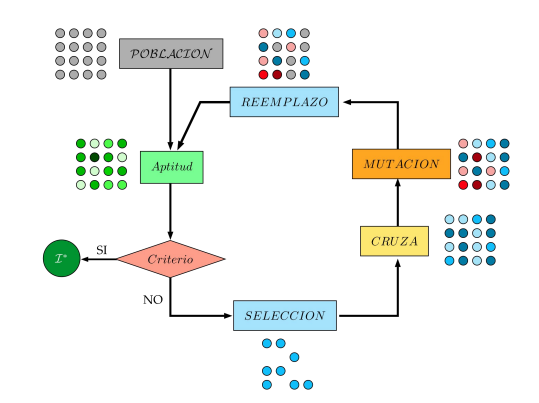

In [33]:
def evaluar_fitness(individual, L, U, funcion_objetivo):
    n_bits_per_var = 32 # Definido en tu análisis de error
    
    # 2. Separar el cromosoma en x e y
    # El individuo es un array de bits de tamaño 64
    bits_x = individual[:n_bits_per_var]
    bits_y = individual[n_bits_per_var:]
    # 3. Convertir arrays de bits a un solo entero decimal (en formato Gray)
    # Este paso es vital para que las operaciones bitwise (>>, ^) funcionen
    int_gray_x = int("".join(bits_x.astype(str)), 2)
    int_gray_y = int("".join(bits_y.astype(str)), 2)
    
    # 4. Decodificación Gray -> Int (Binario puro)
    # Usamos tu función gray_to_int que aplica XOR accumulation
    idx_x = gray_to_int(int_gray_x)
    idx_y = gray_to_int(int_gray_y)
    
    # 5. Transformación Int -> Real
    # Usamos tu función int_to_real basada en la grilla de representaciones
    x_real = int_to_real(idx_x, L, U, n_bits_per_var)
    y_real = int_to_real(idx_y, L, U, n_bits_per_var)
    
    # 6. Calcular y retornar el fitness
    # Aquí invocas la función matemática que quieres optimizar
    return funcion_objetivo(x_real, y_real)

In [48]:
def run_evolution(n_pop, n_gen, n_bits, pc, pm, n_elites, L, U, funcion_objetivo):
    population = np.random.randint(0, 2, (n_pop, n_bits))
    
    for gen in range(n_gen):
        # 1. Evaluar a todos
        fitness = np.array([evaluar_fitness(ind, L, U, funcion_objetivo) for ind in population])
        
        # 2. Elitismo: Guardar a los mejores directamente
        new_population = []
        elites = get_elites(population, fitness, n_elites)
        new_population.extend(elites)
        
        # 3. Selección: Generar el "Mating Pool" completo
        # Esta es la clave: generamos los n_pop padres aquí
        mating_pool = selection_windows(n_pop, fitness, population)
        
        # 4. Cruce y Mutación
        # Usamos los padres del pool para crear los hijos que faltan
        idx_padre = 0
        while len(new_population) < n_pop:
            # Tomamos dos padres del pool
            p1 = mating_pool[idx_padre % n_pop]
            p2 = mating_pool[(idx_padre + 1) % n_pop]
            
            # Cruce (n_bits // 2 porque el individuo tiene x e y)
            c1, c2 = crossover_2point(p1, p2, pc, n_bits // 2)
            
            # Mutación de un bit y guardado
            new_population.append(mutate(c1, pm, n_bits))
            if len(new_population) < n_pop:
                new_population.append(mutate(c2, pm, n_bits))
            
            idx_padre += 2
        
        # 5. Reemplazo total de la población
        population = np.array(new_population)
        
        if gen % 10 == 0:
            print(f"Gen {gen} | Mejor Fitness: {np.min(fitness):.6f}")

    return population

In [68]:
# Parámetros
poblacion_inicial = 1000
generaciones = 50
total_bits = 64 # 32 para x + 32 para y
prob_cruce = 0.8
prob_mutacion = 0.01 # Probabilidad por individuo
elites_por_gen = 2
L =-100
U=100
funcion_objetivo = function_1

# Ejecución
poblacion_final = run_evolution(
    n_pop=poblacion_inicial, 
    n_gen=generaciones, 
    n_bits=total_bits, 
    pc=prob_cruce, 
    pm=prob_mutacion, 
    n_elites=elites_por_gen,
    L=L,
    U=U,
    funcion_objetivo=funcion_objetivo
)

Gen 0 | Mejor Fitness: 0.453150
Gen 10 | Mejor Fitness: 0.039550
Gen 20 | Mejor Fitness: 0.015152
Gen 30 | Mejor Fitness: 0.015149
Gen 40 | Mejor Fitness: 0.015149


In [41]:
10%12

10